In [6]:
import sys
sys.path.append('..')
from src.order_book import OrderBook, Side
from src.market_maker import MarketMaker
from src.simulator import Simulator

import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import math

print("Libraries loaded successfully")

Libraries loaded successfully


# Market Making Simulation — Performance Analysis

Post-hoc analysis of an Avellaneda–Stoikov market making strategy simulated against real BTC-USD trade data from Coinbase Exchange. The notebook covers four areas: raw return metrics, drawdown characteristics, return distribution properties, and regime-conditional performance. A parameter sensitivity analysis via univariate sweeps over γ, κ, α, β, and OFI threshold concludes the analysis.

## 1. Performance Metrics

Core return statistics computed from the per-step PnL series, along with annualised Sharpe using a 5,000-trade normalisation factor.

In [7]:
results = pd.read_csv('../data/simulation_results.csv')

In [ ]:
returns = results['PnL'].diff().dropna()
returns_mean = returns.mean()
returns_std = returns.std()
sharpe = returns_mean / returns_std
sharpe_annualized = (sharpe) * math.sqrt(5000)

In [12]:
print(f"Returns mean: {returns_mean}")
print(f"Returns std: {returns_std}")
print(f"Sharpe Ratio: {sharpe}")
print(f"Annualized Sharpe: {sharpe_annualized}")

Returns mean: 0.0019582223419527048
Returns std: 0.04721444487751016
Sharpe Ratio: 0.041475068637002496
Annualized Sharpe: 2.9327302283401964


## 2. Drawdown Analysis

Running drawdown from the peak PnL equity curve, plotted alongside the mid-price series to contextualise the timing and magnitude of large drawdown episodes.

In [13]:
rolling_max = results['PnL'].cummax()
drawdown = rolling_max - results['PnL']
max_drawdown = drawdown.max()
print(f"Max Drawdown: {max_drawdown}")

Max Drawdown: 19.698076164437225


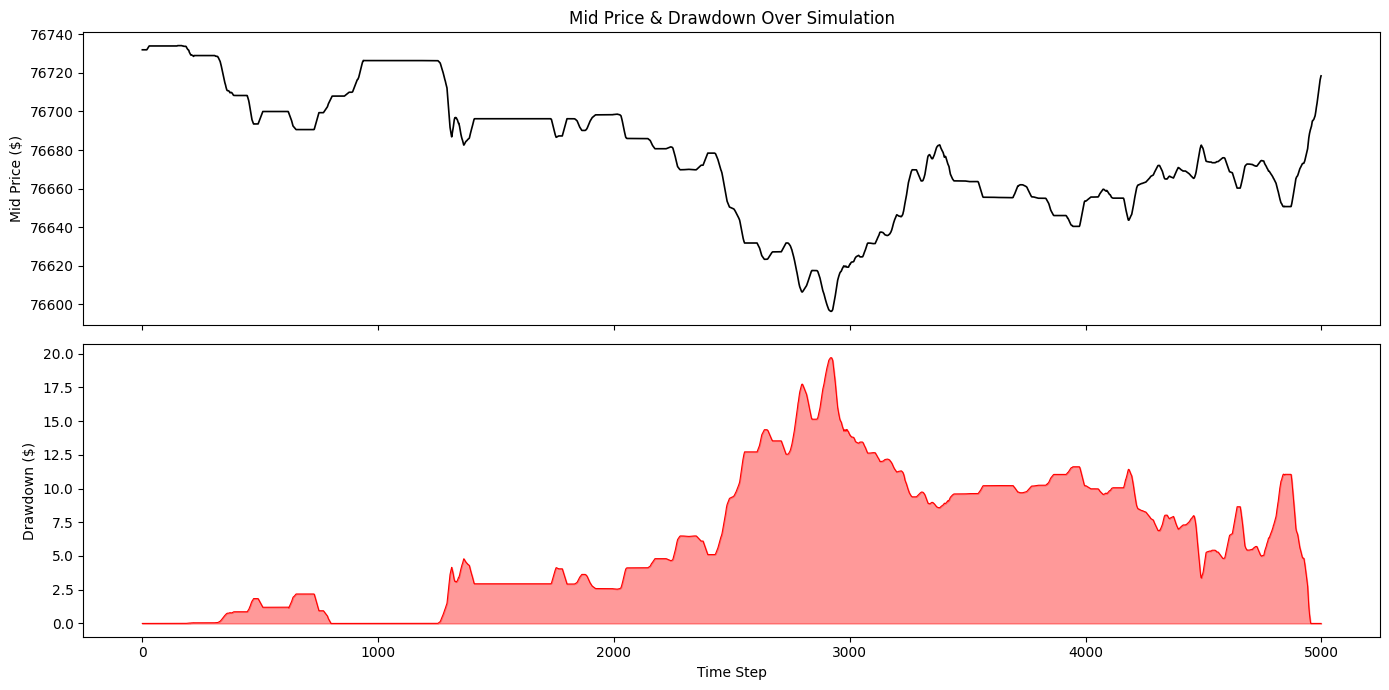

Max Drawdown: $0.0000


In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(results.index, results['Mid_Price'], color='black', linewidth=1.2)
ax1.set_ylabel('Mid Price ($)')
ax1.set_title('Mid Price & Drawdown Over Simulation')

ax2.fill_between(results.index, drawdown, 0, color='red', alpha=0.4)
ax2.plot(results.index, drawdown, color='red', linewidth=0.8)
ax2.set_ylabel('Drawdown ($)')
ax2.set_xlabel('Time Step')

plt.tight_layout()
plt.show()

print(f"Max Drawdown: ${drawdown.min():.4f}")

In [16]:
results.loc[results['Mid_Price'].idxmin()]

Mid_Price            76596.312000
Reservation_Price    76596.312000
Bid                  76594.663090
Ask                  76597.960910
Position                 0.229426
PnL                    -17.227822
Spread                   3.297821
Name: 2919, dtype: float64

## 3. Return Distribution

Higher-order moments and summary statistics of the per-step return series. Skewness and kurtosis characterise tail behaviour; win rate and profit factor assess trade-level profitability.

In [17]:
skewness = returns.skew()
kurtosis = returns.kurtosis()
win_rate = (returns > 0).sum() / len(returns)
avg_win = returns[returns > 0].mean()
avg_loss = returns[returns < 0].mean()
profit_factor = abs(avg_win / avg_loss)

print(f"Skewness: {skewness}")
print(f"Kurtosis: {kurtosis}")
print(f"Win rate: {win_rate}")
print(f"Avg win: {avg_win}")
print(f"Avg loss: {avg_loss}")
print(f"Profit factor: {profit_factor}")

Skewness: 1.378296772001822
Kurtosis: 8.550498306260758
Win rate: 0.3682736547309462
Avg win: 0.035317290594966286
Avg loss: -0.025905243197894636
Profit factor: 1.3633259616661921


## 4. Regime Analysis

The goal is to classify each time step as *trending* or *mean-reverting* and compare strategy performance across regimes. A market maker should theoretically outperform in mean-reverting conditions — where bid-ask spread capture dominates — and underperform in trending regimes, where inventory accumulates in the wrong direction.

Two classification approaches were tested below.

In [28]:
def analyze_regime():
    for regime in ['trending', 'mean_reverting']:
        mask = results['regime'] == regime
        regime_returns = results[mask]['PnL'].diff().dropna()
        regime_sharpe = regime_returns.mean() / regime_returns.std() * math.sqrt(5000)
        print(f"{regime}: Sharpe={regime_sharpe:.2f}, Periods={mask.sum()}")

### Approach 1: Rolling Return Momentum

Classify a period as trending if the rolling mean of price returns exceeds a fixed absolute threshold. This approach failed in practice — the threshold was too conservative and labelled the entire 5,000-step window as mean-reverting, making the classifier useless for comparative analysis.

In [29]:
results['returns_rolling'] = results['Mid_Price'].pct_change().rolling(50).mean()
results['regime'] = results['returns_rolling'].apply(
    lambda x: 'trending' if abs(x) > 0.00005 else 'mean_reverting'
)

analyze_regime()

trending: Sharpe=nan, Periods=0
mean_reverting: Sharpe=2.93, Periods=5000


### Approach 2: Price Deviation from Rolling Mean

Classify the top 25th percentile of absolute price deviations from a 100-step rolling mean as trending. This produces a more balanced split (~75% mean-reverting, ~25% trending) and is used for the final regime comparison.

In [30]:
rolling_mean = results['Mid_Price'].rolling(100).mean()
deviation = abs(results['Mid_Price'] - rolling_mean) / rolling_mean
threshold = deviation.quantile(0.75)

results['regime'] = (deviation > threshold).map({True: 'trending', False: 'mean_reverting'})
results['regime'] = results.apply(
    lambda row: 'trending' if abs(row['Mid_Price'] - rolling_mean[row.name]) > rolling_mean[row.name] * threshold else 'mean_reverting', axis=1
)

analyze_regime()

trending: Sharpe=2.45, Periods=1226
mean_reverting: Sharpe=-0.65, Periods=3774


### Observations

The simulation data is predominantly mean-reverting under the rolling-deviation classifier (~75% of steps). The strategy shows a positive Sharpe ratio in trending regimes, but this is largely attributable to **incidental directional exposure** rather than pure spread capture. During large price moves, an accumulated inventory position generates outsized PnL in either direction — this constitutes luck rather than a systematic edge. In mean-reverting regimes, where spread capture should theoretically dominate, performance is negative, indicating that current parameter calibration is insufficient.

### Root Causes

The core issue is that the **inventory penalty is effectively zero** due to a sigma unit mismatch:

- σ is computed as a **proportional return** (dimensionless), not in dollar terms. The inventory penalty `γσ²q` therefore produces negligibly small reservation price adjustments regardless of γ.
- The **reservation price tracks the mid-price** almost exactly, defeating its purpose. The spread is dynamic, but its centre is pinned to the mid — the model degenerates to a symmetric spread around mid-price.
- **γ is too small** to generate meaningful inventory skew even if sigma were correctly scaled.

### Candidates for Improvement

- Express σ in **dollar terms** (price-level standard deviation, not proportional returns)
- Increase γ to produce a meaningful reservation price skew relative to inventory
- Systematically tune κ and OFI threshold — the two parameters with demonstrated leverage on performance
- Consider Bayesian optimisation for joint parameter search once sigma is corrected

## 5. Parameter Sensitivity Analysis

Univariate sweeps over each model parameter, holding all others at baseline. Each data point represents the Sharpe ratio from a full simulation run. The goal is to identify which parameters have the most leverage on performance and to surface reasonable starting points for joint optimisation.

In [8]:
def get_btc_trades_extended(n_batches=5):
    url = "https://api.exchange.coinbase.com/products/BTC-USD/trades"
    all_trades = []

    params = {"limit": 1000}
    for _ in range(n_batches):
        response = requests.get(url, params=params)
        batch = response.json()
        if not batch:
            break
        all_trades.extend(batch)
        oldest_id = min(t["trade_id"] for t in batch)
        params = {"limit": 1000, "after": oldest_id}

    df = pd.DataFrame(all_trades)
    df["price"] = pd.to_numeric(df["price"])
    df["size"] = pd.to_numeric(df["size"])
    df["time"] = pd.to_datetime(df["time"])
    df = df.drop_duplicates(subset="trade_id")
    df = df.sort_values("time").reset_index(drop=True)
    df = df.set_index("time")
    return df

In [9]:
trades = get_btc_trades_extended()
print(f"Got {len(trades)} trades")

Got 5000 trades


In [10]:
import numpy as np

gammas = np.linspace(0.05, 0.5, 20)
kappas = np.linspace(1.0, 20.0, 20)
alphas = np.linspace(0.05, 3.0, 20)
betas = np.linspace(0.05, 3.0, 20)
ofi_thresholds = np.linspace(0.5, 0.9, 20)

In [11]:
def run_simulation(gamma=0.1, kappa=1.5, alpha=1.0, beta=1.0, ofi_threshold=0.8, mid_price_window=20):
    book = OrderBook()
    mm = MarketMaker(starting_wealth=100000, order_book=book, gamma=gamma, kappa=kappa, alpha=alpha, beta=beta)
    sim = Simulator(mm, book, trades, mid_price_window)
    sim.run(ofi_threshold)
    sim_results = sim.get_results()
    returns = sim_results['PnL'].diff().dropna()
    return returns.mean() / returns.std()

In [12]:
def plot_param(**kwargs):
    assert len(kwargs) == 1, "Pass exactly one parameter to sweep, e.g. plot_param(gamma=gammas)"
    param_name, param_list = next(iter(kwargs.items()))

    sharpes = [run_simulation(**{param_name: x}) for x in param_list]

    plt.figure(figsize=(10, 4))
    plt.plot(param_list, sharpes, marker='o', markersize=3)
    plt.xlabel(param_name)
    plt.ylabel('Sharpe Ratio')
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    plt.title(f'Sharpe vs {param_name}')
    plt.tight_layout()
    plt.show()

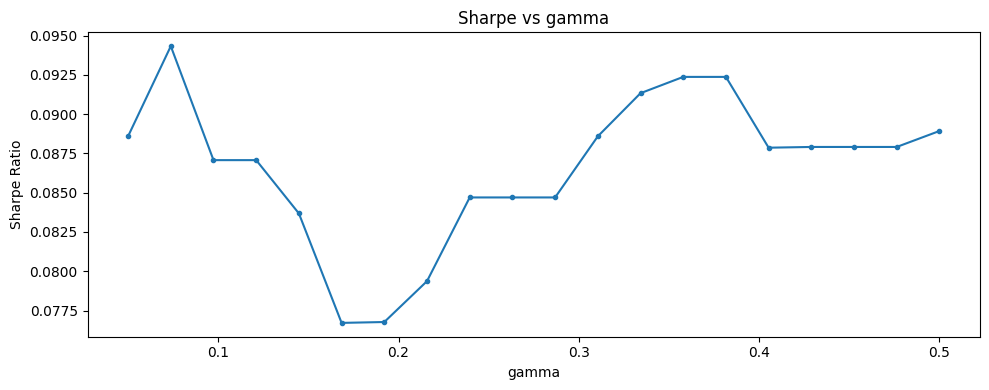

In [47]:
plot_param(gamma=gammas)

**γ (Inventory Risk Aversion):** Noisy with no clear monotonic relationship across the tested range. The lack of sensitivity is a direct consequence of the sigma unit mismatch — with σ expressed as a proportional return, the inventory penalty `γσ²q` is negligibly small regardless of γ. This parameter cannot be meaningfully tuned until σ is corrected.

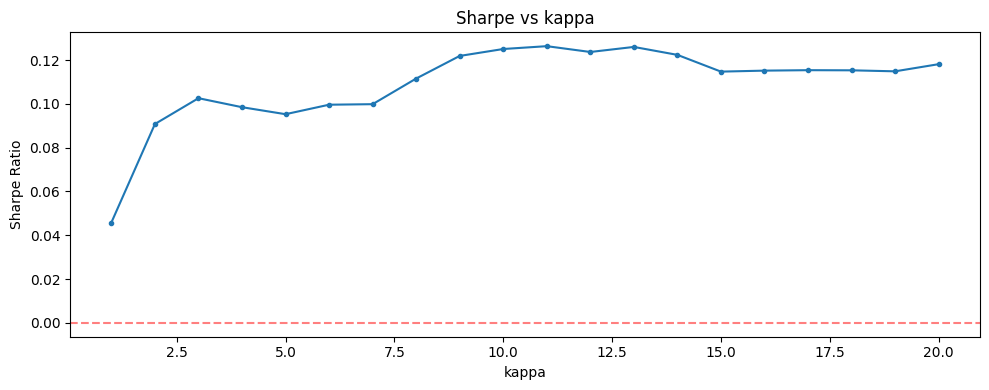

In [56]:
plot_param(kappa=kappas)

**κ (Order Arrival Rate / Spread Scaling):** The most impactful parameter tested. Higher κ values consistently improve Sharpe, with the optimal region in the range of 10–12. κ directly controls spread width via the liquidity term `(2/γ) log(1 + γ/κ)` — larger κ compresses the spread, increasing fill frequency at the cost of per-trade margin.

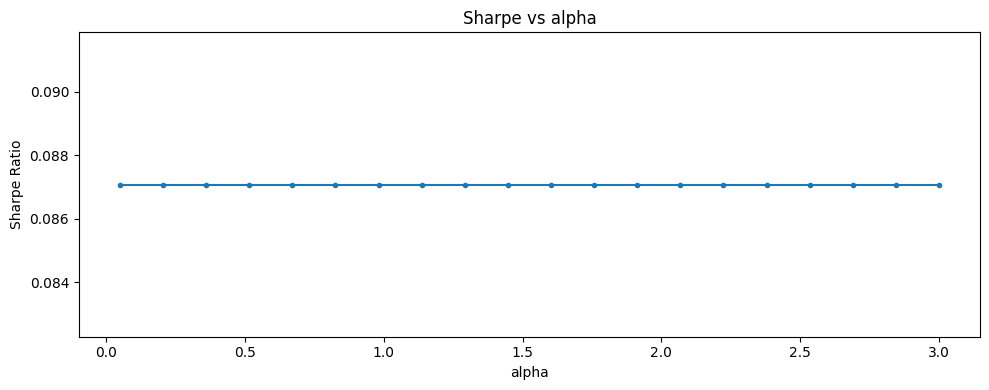

In [49]:
plot_param(alpha=alphas)

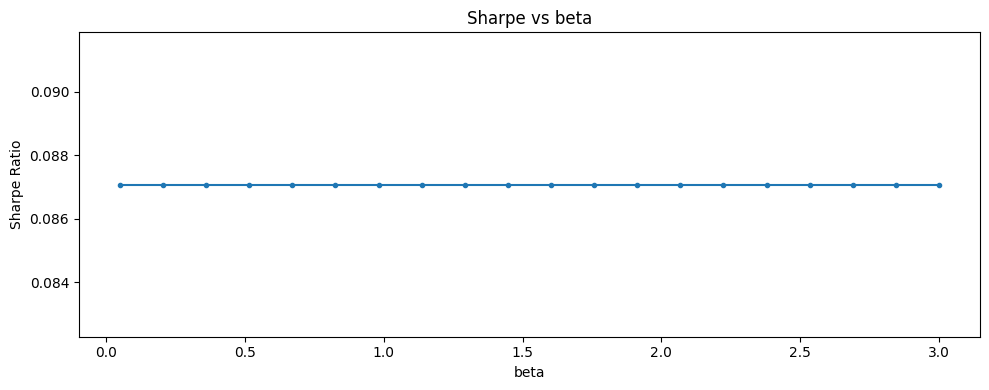

In [50]:
plot_param(beta=betas)

**α and β (Dynamic Spread Parameters):** Both show a completely flat Sharpe profile — varying them has no effect. This is a direct consequence of the sigma unit issue: with a near-zero inventory penalty, the dynamic adjustments to reservation price and spread driven by α and β have no meaningful impact on quoting behaviour. Re-evaluate after σ is fixed.

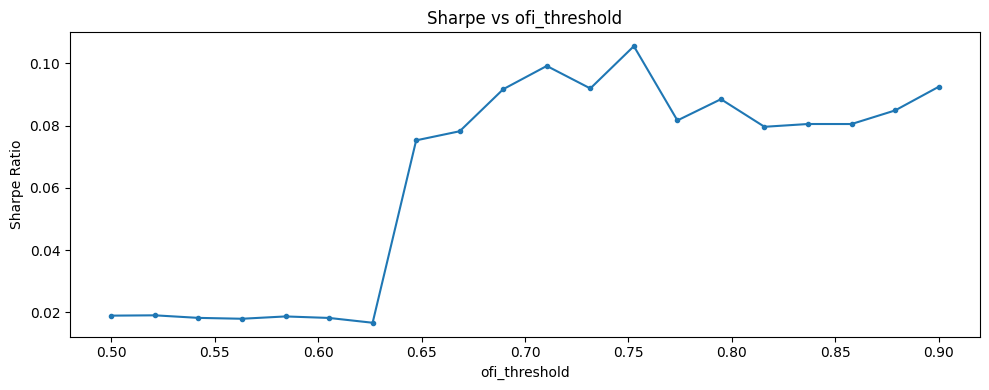

In [51]:
plot_param(ofi_threshold=ofi_thresholds)

**OFI Threshold (Adverse Selection Filter):** A clear non-linear relationship with a critical cliff near 0.5–0.6. Setting the threshold too low causes the market maker to pause quoting too frequently, destroying fill opportunities. The sweet spot sits around 0.75, balancing adverse selection protection against market participation rate.

### Summary

| Priority | Parameter | Finding |
|----------|-----------|---------|
| Critical | σ (sigma) | Must be expressed in dollar terms — current unit mismatch renders γ, α, β inert |
| High | κ | Dominant driver of performance; optimal range 10–12 |
| High | OFI threshold | Non-linear cliff effect; optimal ~0.75 |
| Low | γ, α, β | Effectively inert until σ is corrected; re-sweep after fix |

**Next step:** Bayesian optimisation over κ and OFI threshold as the two most actionable parameters in the current implementation.

In [ ]:
# Before sigma fix
# gamma_sharpes_before = [run_simulation(gamma=g) for g in gammas]
# alpha_sharpes_before = [run_simulation(alpha=a) for a in alphas]
# beta_sharpes_before = [run_simulation(beta=b) for b in betas]

# print(gamma_sharpes_before)
# print(alpha_sharpes_before)
# print(beta_sharpes_before)

[np.float64(0.08859277953263327), np.float64(0.09432477751602483), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08368013641808902), np.float64(0.07671657313079289), np.float64(0.07677172856182582), np.float64(0.07937211570665699), np.float64(0.08469871991257624), np.float64(0.08469870199924265), np.float64(0.08469867583172758), np.float64(0.08858796390669178), np.float64(0.09133269501079065), np.float64(0.09236915671548625), np.float64(0.09236915671548625), np.float64(0.08786466783542524), np.float64(0.08791138494051226), np.float64(0.0879113259211839), np.float64(0.0879113259211839), np.float64(0.08892668030593294)]
[np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64

In [13]:
# Hard code before values for analysis
gamma_sharpes_before = [np.float64(0.08859277953263327), np.float64(0.09432477751602483), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08368013641808902), np.float64(0.07671657313079289), np.float64(0.07677172856182582), np.float64(0.07937211570665699), np.float64(0.08469871991257624), np.float64(0.08469870199924265), np.float64(0.08469867583172758), np.float64(0.08858796390669178), np.float64(0.09133269501079065), np.float64(0.09236915671548625), np.float64(0.09236915671548625), np.float64(0.08786466783542524), np.float64(0.08791138494051226), np.float64(0.0879113259211839), np.float64(0.0879113259211839), np.float64(0.08892668030593294)]
alpha_sharpes_before = [np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718)]
beta_sharpes_before = [np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718), np.float64(0.08707301994402718)]

In [14]:
# After sigma fix
gamma_sharpes_after = [run_simulation(gamma=g) for g in gammas]
alpha_sharpes_after = [run_simulation(alpha=a) for a in alphas]
beta_sharpes_after = [run_simulation(beta=b) for b in betas]

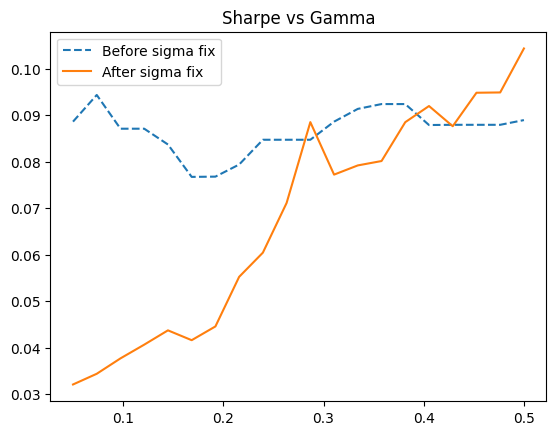

In [18]:
plt.plot(gammas, gamma_sharpes_before, label='Before sigma fix', linestyle='--')
plt.plot(gammas, gamma_sharpes_after, label='After sigma fix')
plt.title(f'Sharpe vs Gamma')
plt.legend()

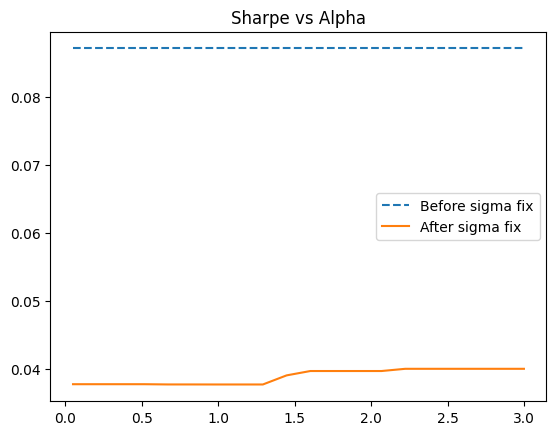

In [19]:
plt.plot(alphas, alpha_sharpes_before, label='Before sigma fix', linestyle='--')
plt.plot(alphas, alpha_sharpes_after, label='After sigma fix')
plt.title(f'Sharpe vs Alpha')
plt.legend()

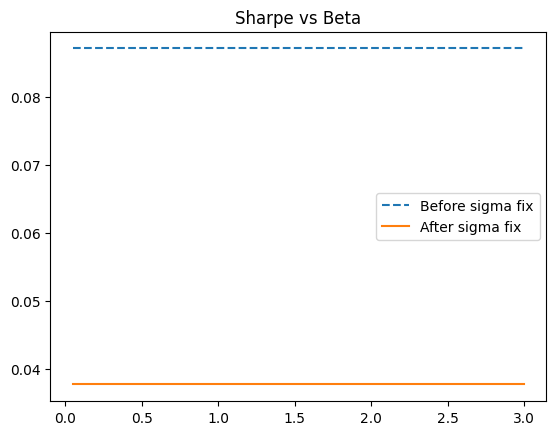

In [20]:
plt.plot(betas, beta_sharpes_before, label='Before sigma fix', linestyle='--')
plt.plot(betas, beta_sharpes_after, label='After sigma fix')
plt.title(f'Sharpe vs Beta')
plt.legend()

**Extended γ sweep:** Gamma shows meaningful improvement at higher values. Extending the range to confirm the peak and check for instability at large values.

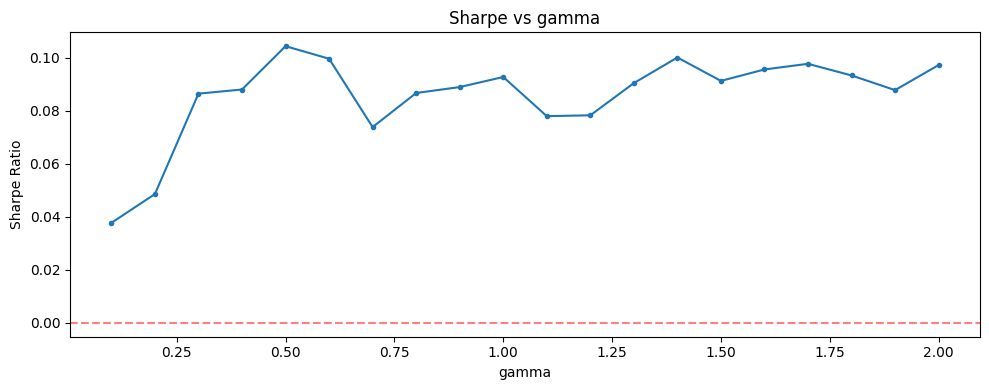

In [22]:
gammas = np.linspace(0.1, 2.0, 20)
plot_param(gamma=gammas)

Optimal γ is approximately 0.5. Performance degrades and becomes noisy beyond that point — charging more for inventory risk provides no further benefit and introduces instability.

### Optimal Parameters — Univariate Results

Best Sharpe ratio achieved by each parameter in isolation, with all others held at baseline. Results are indicative rather than definitive — univariate sweeps do not capture interaction effects between parameters.

| Parameter | Optimal Value | Sharpe Ratio | Notes |
|-----------|:------------:|:------------:|-------|
| `gamma` (γ) | 0.5 | 0.103 | Noisy beyond peak; instability at high values |
| `kappa` (κ) | 10 – 12 | 0.125 | Strongest driver; tighter spread → higher fill rate |
| `ofi_threshold` | 0.75 | 0.105 | Critical cliff below ~0.6 |
| `alpha` (α) | — | — | Inconclusive; inert due to σ unit mismatch |
| `beta` (β) | — | — | Inconclusive; inert due to σ unit mismatch |

## 6. Final Simulation with Optimal Parameters

Plugging in optimal parameters and looking at full performance summary.

In [26]:
book = OrderBook()
mm = MarketMaker(
    starting_wealth=100000, 
    order_book=book, 
    gamma=0.5,
    kappa=11.0
)
sim = Simulator(mm, book, trades, window=20)
mm.start_session()
sim.run(pause_threshold=0.75)
results = sim.get_results()

## Performance Summary

In [27]:
rolling_max = results['PnL'].cummax()
drawdown = rolling_max - results['PnL']

returns = results['PnL'].diff().dropna()
sharpe = returns.mean() / returns.std()
max_drawdown = drawdown.max()
win_rate = (returns > 0).sum() / len(returns)
avg_win = returns[returns > 0].mean()
avg_loss = returns[returns < 0].mean()
profit_factor = abs(avg_win / avg_loss)
final_pnl = results['PnL'].iloc[-1]
final_position = results['Position'].iloc[-1]

print("=" * 35)
print("       PERFORMANCE SUMMARY")
print("=" * 35)
print(f"  Sharpe Ratio     : {sharpe:.4f}")
print(f"  Max Drawdown     : ${max_drawdown:.4f}")
print(f"  Win Rate         : {win_rate:.2%}")
print(f"  Profit Factor    : {profit_factor:.4f}")
print(f"  Final PnL        : ${final_pnl:.4f}")
print(f"  Final Position   : {final_position:.6f} BTC")
print("=" * 35)

       PERFORMANCE SUMMARY
  Sharpe Ratio     : 0.0540
  Max Drawdown     : $26.7030
  Win Rate         : 46.71%
  Profit Factor    : 1.2084
  Final PnL        : $23.7795
  Final Position   : 0.333910 BTC


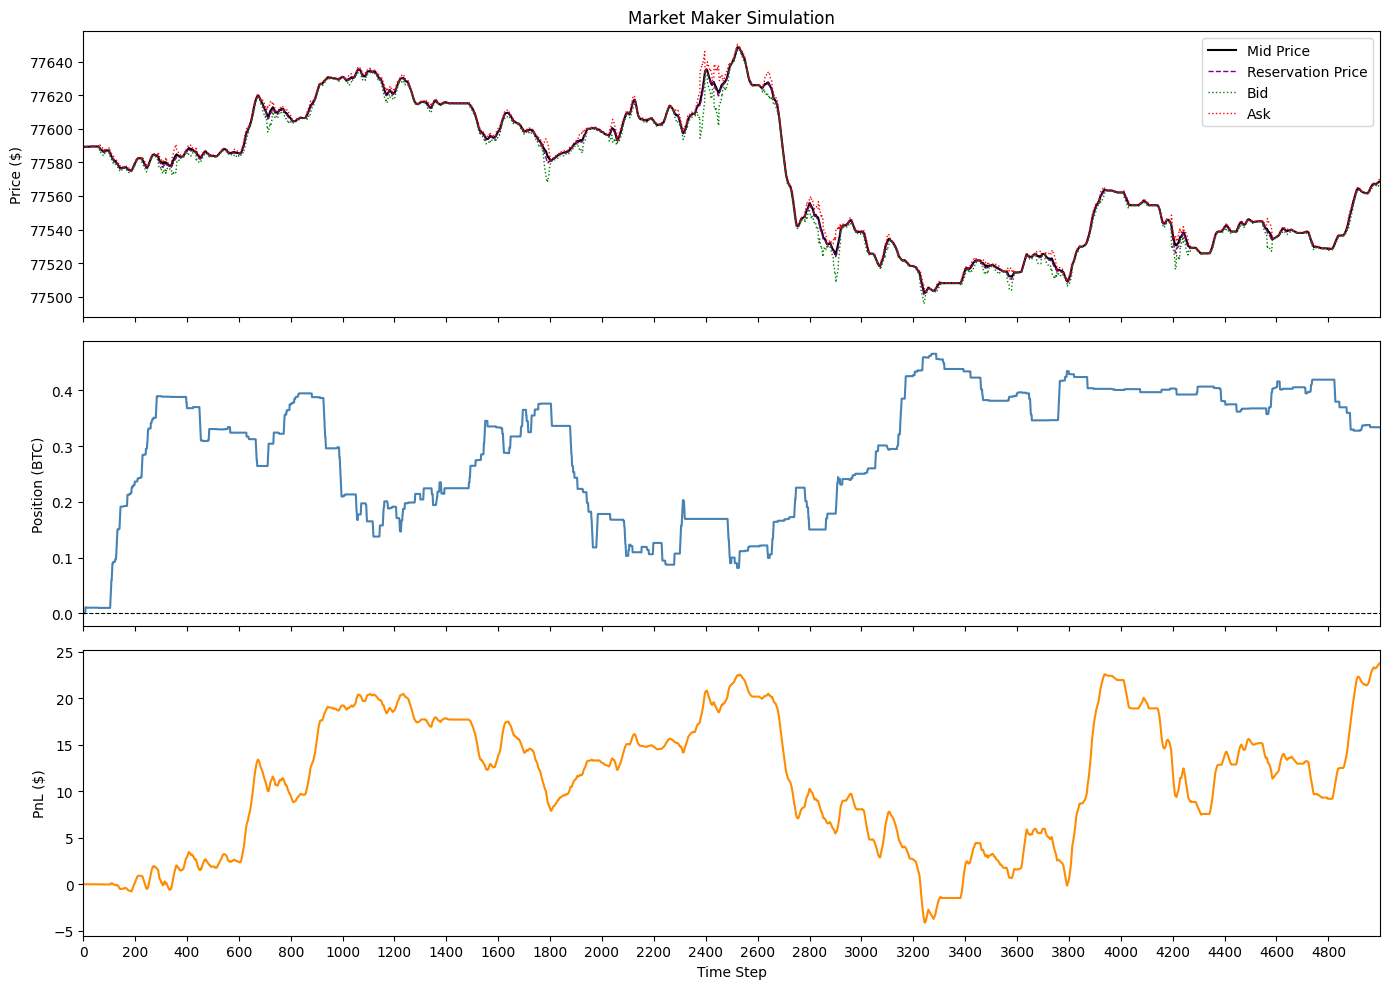

In [28]:
from matplotlib.ticker import MultipleLocator

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

ax1.plot(results.index, results['Mid_Price'], label='Mid Price', color='black', linewidth=1.5)
ax1.plot(results.index, results['Reservation_Price'], label='Reservation Price', color='purple', linewidth=1, linestyle='--')
ax1.plot(results.index, results['Bid'], label='Bid', color='green', linewidth=1, linestyle=':')
ax1.plot(results.index, results['Ask'], label='Ask', color='red', linewidth=1, linestyle=':')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper right')
ax1.set_title('Market Maker Simulation')
ax1.set_xlim(results.index[0], results.index[-1])

ax2.plot(results.index, results['Position'], color='steelblue', linewidth=1.5)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_ylabel('Position (BTC)')

ax3.plot(results.index, results['PnL'], color='darkorange', linewidth=1.5)
ax3.set_ylabel('PnL ($)')
ax3.set_xlabel('Time Step')
ax3.xaxis.set_major_locator(MultipleLocator(200))


plt.tight_layout()
plt.show()

In [29]:
print(f"{'Metric':<20} {'Baseline':>12} {'Optimized':>12}")
print(f"{'Sharpe':<20} {0.041:>12.3f} {0.054:>12.3f}")
print(f"{'Max Drawdown':<20} {19.70:>12.2f} {26.70:>12.2f}")
print(f"{'Win Rate':<20} {36.8:>12.1f}% {46.71:>12.1f}%")
print(f"{'Profit Factor':<20} {1.363:>12.3f} {1.208:>12.3f}")
print(f"{'Final PnL':<20} {2.93:>12.2f} {23.78:>12.2f}")

Metric                   Baseline    Optimized
Sharpe                      0.041        0.054
Max Drawdown                19.70        26.70
Win Rate                     36.8%         46.7%
Profit Factor               1.363        1.208
Final PnL                    2.93        23.78


### Results

**The Good**

- **Final PnL: +$23.78** — solidly profitable
- **Win rate: 46.71%** — much closer to 50% than before (was 36.8%). Optimized parameters are getting fills more evenly on both sides
- **Profit factor: 1.21** — for every $1 lost, $1.21 is made
- **Bid and ask now visible on the chart** — wider spread from higher κ is clearly visible
- **Position oscillates** — bouncing between 0.1 and 0.45 BTC, not drifting to infinity

**The Concerning**

- **Sharpe: 0.054** — lower than the sensitivity analysis suggested.
- **Max drawdown: $26.70** — larger than the peak early PnL of ~$20. The sharp drop around step 3000–3200 corresponds to the price crash from $77,640 to $77,500.
- **Final position: 0.33 BTC** — still carrying meaningful inventory at end of session.


## 7. Final Thoughts & Future Work

Optimization improved most metrics but hurt others — this is expected. Higher κ compresses the spread, increasing fill frequency and win rate, but it also means each fill carries more directional exposure when inventory works against the strategy. The trade-off between spread capture and inventory risk is fundamental to market making, and the current implementation does not yet manage it well enough to consistently profit from both.

### Future Work

| Priority | Item | Expected Impact |
|----------|------|----------------|
| High | **Fix σ unit mismatch** — express sigma in dollar terms | Activates the inventory penalty; enables meaningful γ, α, β tuning |
| High | **Bayesian optimisation with corrected σ** — joint search over γ, κ, and OFI threshold | More efficient than univariate sweeps; captures parameter interactions |
| Medium | **Regime-adaptive parameter switching** — tighten spreads in mean-reverting regimes, widen in trending | Reduces inventory accumulation during directional price moves |
| Medium | **Inventory-aware quote sizing** — scale down quote size as position grows | Limits max drawdown during adverse inventory episodes |
| Low | **Session-end inventory unwind** — force position toward zero near session close | Eliminates residual position risk carried at end of simulation |